### Adaptation
Edit the numbers marked `👈` and re-run.

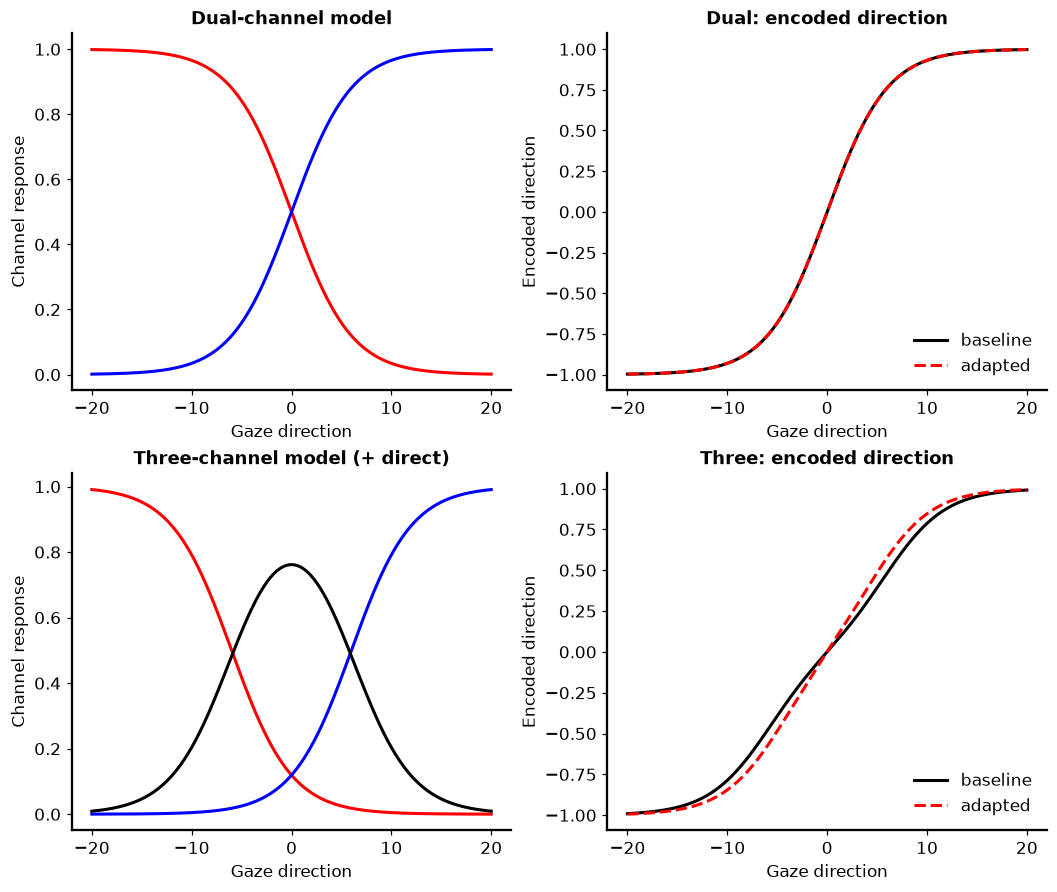

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

gazeDirs = np.linspace(-20, 20, 400)
slope = 3.0
adaptor = 0.0          # 👈 adaptor gaze direction (0 = direct gaze)
alpha   = 0.5          # 👈 adaptation strength
hm_dual, hm_three = 0.0, 6.0

LG = lambda d, hm: 1/(1+np.exp((d+hm)/slope))
RG = lambda d, hm: 1/(1+np.exp(-(d-hm)/slope))
DG = lambda d, hm: np.maximum(1-(LG(d,hm)+RG(d,hm)), 0)

def adapt(ch, hm):     # weaken a channel in proportion to its response to the adaptor
    return (1 - alpha*ch(adaptor, hm)) * ch(gazeDirs, hm)

# encoded direction = balance of channel activity
respDC  = (RG(gazeDirs,hm_dual)-LG(gazeDirs,hm_dual))/(RG(gazeDirs,hm_dual)+LG(gazeDirs,hm_dual))
respDCA = (adapt(RG,hm_dual)-adapt(LG,hm_dual))/(adapt(RG,hm_dual)+adapt(LG,hm_dual))
den_t  = RG(gazeDirs,hm_three)+DG(gazeDirs,hm_three)+LG(gazeDirs,hm_three)
respTC = (RG(gazeDirs,hm_three)-LG(gazeDirs,hm_three))/den_t
den_tA = adapt(RG,hm_three)+adapt(DG,hm_three)+adapt(LG,hm_three)
respTCA= (adapt(RG,hm_three)-adapt(LG,hm_three))/den_tA

fig, axs = plt.subplots(2, 2, figsize=(9.5, 8), constrained_layout=True)
axs[0,0].plot(gazeDirs, LG(gazeDirs,hm_dual), "r", lw=2)
axs[0,0].plot(gazeDirs, RG(gazeDirs,hm_dual), "b", lw=2)
axs[0,0].set(title="Dual-channel model", xlabel="Gaze direction", ylabel="Channel response")
axs[1,0].plot(gazeDirs, LG(gazeDirs,hm_three), "r", lw=2)
axs[1,0].plot(gazeDirs, RG(gazeDirs,hm_three), "b", lw=2)
axs[1,0].plot(gazeDirs, DG(gazeDirs,hm_three), "k", lw=2)
axs[1,0].set(title="Three-channel model (+ direct)", xlabel="Gaze direction", ylabel="Channel response")
axs[0,1].plot(gazeDirs, respDC, "k", lw=2, label="baseline")
axs[0,1].plot(gazeDirs, respDCA, "r", ls="--", lw=2, label="adapted")
axs[0,1].set(title="Dual: encoded direction", xlabel="Gaze direction", ylabel="Encoded direction")
axs[0,1].legend(loc="lower right")
axs[1,1].plot(gazeDirs, respTC, "k", lw=2, label="baseline")
axs[1,1].plot(gazeDirs, respTCA, "r", ls="--", lw=2, label="adapted")
axs[1,1].set(title="Three: encoded direction", xlabel="Gaze direction", ylabel="Encoded direction")
axs[1,1].legend(loc="lower right")
plt.show()
